# VPIN / order flow — desk synthesis

**Pass 1 complete:** warehouse trade tape — **panel_exploratory** n_ok=226 (HL+DB+Kraken, complete UTC); **panel_promote** n_ok=139 (HL+DB only). Kraken: real tape, Hold arm. HL SOL empty on inventory probe.

**SoT:** [`DESK_MEMO.md`](../DESK_MEMO.md) · [`CHAPTER_INDEX.md`](../CHAPTER_INDEX.md) · [`TRADING_APPLICATIONS.md`](../TRADING_APPLICATIONS.md) · `out/vpin_panel/decisions.json` + `decisions_panel_promote.json`


## 0. Setup


In [1]:
from pathlib import Path
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

BOOK = Path(os.environ.get('ARES_MICROSTRUCTURE') or (Path.home() / 'srv' / 'ares-microstructure')) / 'research' / 'books' / 'vpin_of'
OUT = BOOK / 'out'
FIGS = OUT / 'desk_synthesis' / 'figs'

def jload(rel):
    p = OUT / rel
    return json.loads(p.read_text()) if p.is_file() else {}

def jlines(rel):
    p = OUT / rel
    if not p.is_file():
        return []
    return [json.loads(ln) for ln in p.read_text().splitlines() if ln.strip()]

def show_fig(name, caption=None):
    p = FIGS / name
    if caption:
        display(Markdown(f'**{caption}** — `{p.relative_to(BOOK)}`'))
    if p.exists():
        display(Image(filename=str(p)))
    else:
        display(Markdown(f'*missing* `{p}` — run `scripts/build_notebook_figs.py`'))

dec = jload('pass2/decisions_pass2.json') or jload('vpin_panel/decisions.json')
dec_promote = jload('vpin_panel/decisions_panel_promote.json')
rows = jlines('vpin_panel/rows.jsonl')
panel_ext = jload('pass2/panel_hl_db_extended.json')
ok_rows = panel_ext if isinstance(panel_ext, list) and panel_ext else [r for r in rows if r.get('ok')]
p2 = jload('pass2/pass2_summary.json')
print('pass2' if p2 else 'pass1', 'n_ok', dec.get('n_ok'), 'promote n_ok', dec_promote.get('n_ok'), 'counts', dec.get('decision_counts'))


pass2 n_ok 226 promote n_ok 139 counts {'Promote': 6, 'Hold': 5}


## 1. Signal board


**Pass 1 decision board** — `out/desk_synthesis/figs/signal_board.png`

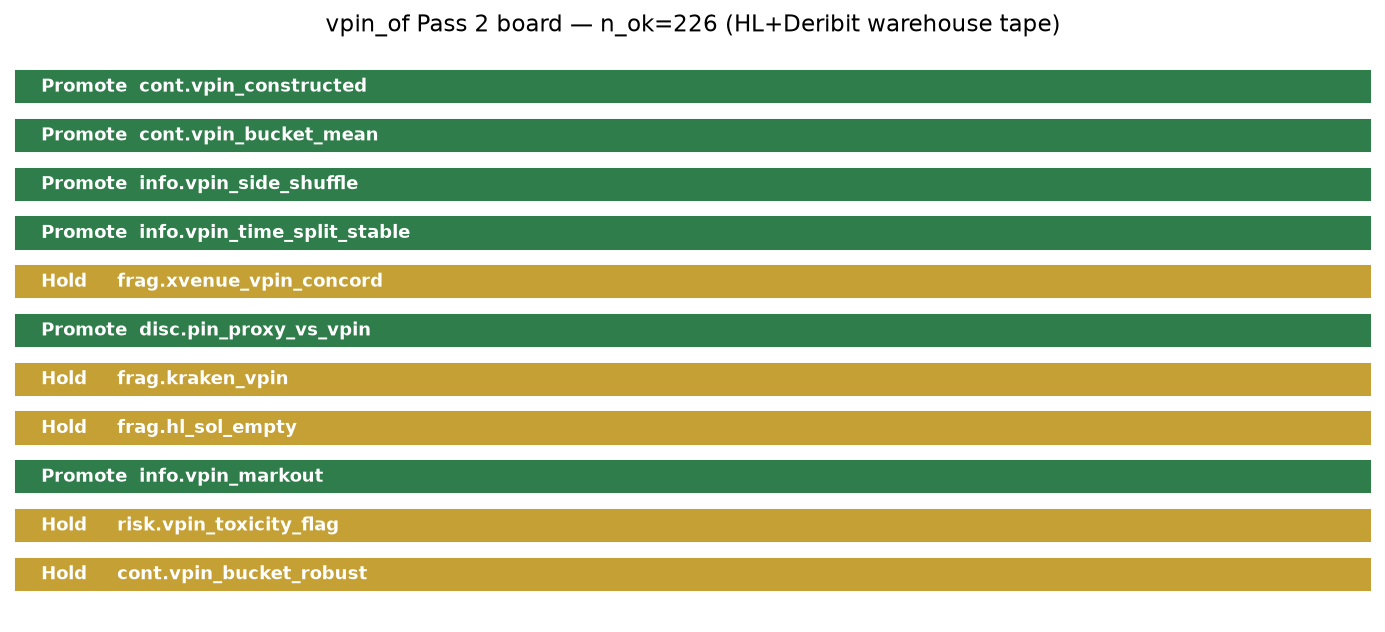

,id,decision,evidence
0,cont.vpin_constructed,Promote,n_ok=226 HL+DB=139; med mean_vpin bootstrap={'...
1,cont.vpin_bucket_mean,Promote,median×50 SoT; n_ok=226
2,info.vpin_side_shuffle,Promote,pass_rate=0.98 (p_exceed≤0.05); n_ok=226
3,info.vpin_time_split_stable,Promote,stable_rate=0.97 |Δearly-late|<0.12; n_ok=226
4,frag.xvenue_vpin_concord,Hold,HL↔DB ρ=-0.32177921967045164 CI=[-0.5561982412...
5,disc.pin_proxy_vs_vpin,Promote,day-level proxy vs mean_vpin Spearman (not EHO...
6,frag.kraken_vpin,Hold,Kraken strict_complete=30 standard_complete=87...
7,frag.hl_sol_empty,Hold,Warehouse mercat-hyperliquid-md returns n=0 fo...
8,info.vpin_markout,Promote,n_ok=36 medIC=0.0224 early=0.0304 late=0.0147
9,risk.vpin_toxicity_flag,Hold,"n=73 ρ_vpin,spread=-0.36403184005923733"


In [2]:
show_fig('signal_board.png', 'Pass 1 decision board')
if dec.get('decision_table'):
    display(pd.DataFrame(dec['decision_table']))


## 2. Panel coverage


n_ok  med_vpin  med_buckets   med_cov
venue       symbol                                       
deribit     BTC       28  0.878528       9251.5  0.991097
            ETH       28  0.746376       5571.0  0.990764
hyperliquid BTC       27  0.824920      10516.0  0.990819
            ETH       27  0.788693       8075.0  0.990822

**Day mean VPIN** — `out/desk_synthesis/figs/fig_vpin_by_day.png`

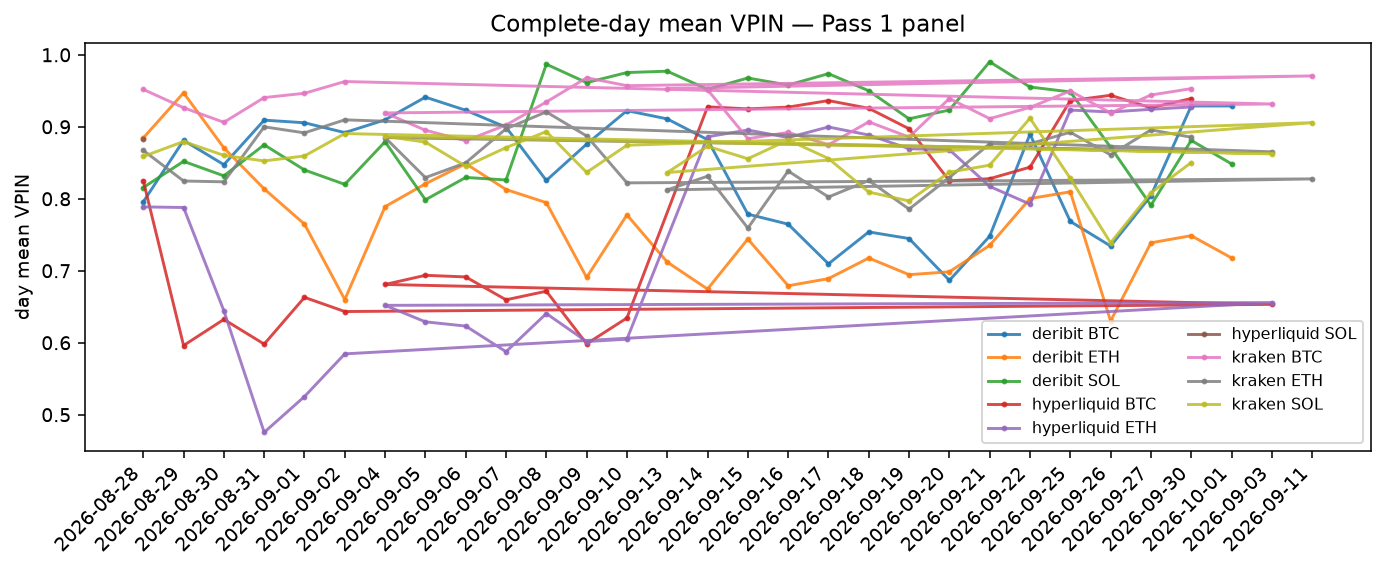

In [3]:
if ok_rows:
    d = pd.DataFrame(ok_rows)
    display(d.groupby(['venue','symbol']).agg(
        n_ok=('day','count'), med_vpin=('mean_vpin','median'),
        med_buckets=('n_buckets','median'), med_cov=('coverage','median')))
show_fig('fig_vpin_by_day.png', 'Day mean VPIN')


## 3. Bucket calibration


,method,bucket_scale,bucket_volume,n_buckets,mean_vpin,p50_vpin,target_buckets
0,median_x_25,25.0,2.860000,37069,0.939004,0.950977,NaN
1,median_x_50,50.0,5.720000,27382,0.927529,0.938370,NaN
2,median_x_100,100.0,11.440000,18324,0.902497,0.913250,NaN
3,target_30_buckets,NaN,13372.998820,29,0.216184,0.216184,30.0
4,target_50_buckets,NaN,8023.799292,49,0.310745,0.310745,50.0
5,target_100_buckets,NaN,4011.899646,99,0.451835,0.457745,100.0


**Bucket scale grid (smoke day)** — `out/desk_synthesis/figs/fig_bucket_calibration.png`

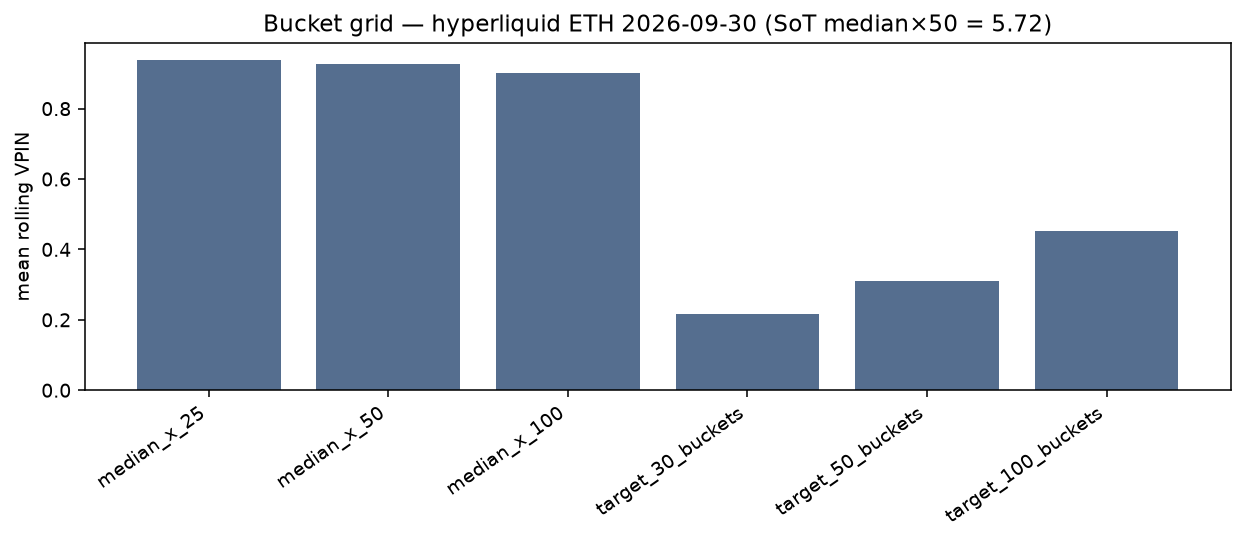

Keep median(qty)×50 as SoT (matches empirical_mm Ch.15 / continuous.vpin_bucket). High rolling mean_vpin (~0.6–0.95) on crypto is expected: 50-bucket roll smooths micro-bucket imbalances; levels are not comparable to EHO PIN∈(0,1). Use target_buckets≈50 only for robustness / level diagnostics, not Promote gates.

In [4]:
cal = jload('vpin_panel/bucket_calibration.json')
if cal.get('grid'):
    display(pd.DataFrame(cal['grid']))
show_fig('fig_bucket_calibration.png', 'Bucket scale grid (smoke day)')
display(Markdown(cal.get('desk_choice','')))


## 4. Falsifiers + cross-venue


**Side-shuffle + time-split** — `out/desk_synthesis/figs/fig_falsifier_rates.png`

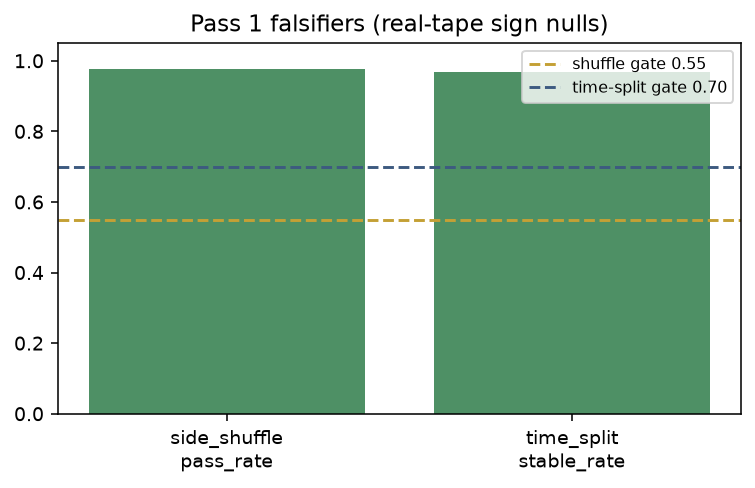

**HL vs Deribit paired days** — `out/desk_synthesis/figs/fig_xvenue_scatter.png`

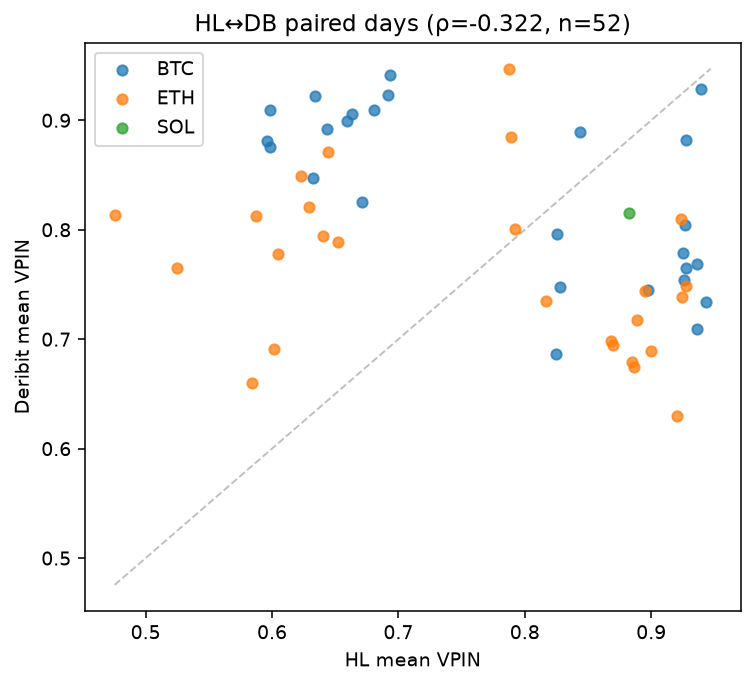

{'side_shuffle_pass_rate': 0.9778761061946902,
 'time_split_stable_rate': 0.9690265486725663,
 'xvenue_spearman': {'n': 52.0,
  'rho': -0.32177921967045164,
  'lo': -0.5561982412703833,
  'hi': -0.05243105950653127}}

In [5]:
show_fig('fig_falsifier_rates.png', 'Side-shuffle + time-split')
show_fig('fig_xvenue_scatter.png', 'HL vs Deribit paired days')
display(dec.get('falsifiers', {}))


## 5. PIN compare (proxy only)


**Day-level Spearman vs pin_proxy** — `out/desk_synthesis/figs/fig_pin_proxy_spearman.png`

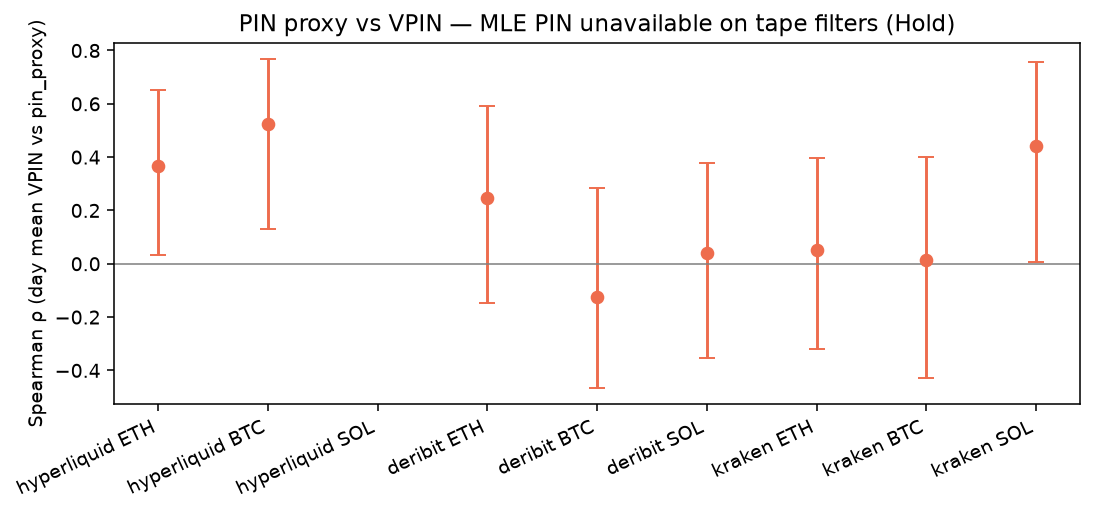

,venue,symbol,n_ok_days,mle,proxy,vpin_pooled,compare,day_mean_vpin_vs_pin_proxy_spearman
0,hyperliquid,ETH,27,"{'ok': True, 'n_days': 27, 'n_days_raw': 27, '...","{'n_days': 27, 'pin_proxy': 0.0664459896830331...","{'n_buckets': 298562, 'mean_vpin': 0.845497196...","{'pin': 0.17414844359655826, 'pin_ok': True, '...","{'n': 27.0, 'rho': 0.36568986568986567, 'lo': ..."
1,hyperliquid,BTC,27,"{'ok': True, 'n_days': 27, 'n_days_raw': 27, '...","{'n_days': 27, 'pin_proxy': 0.0565425296045885...","{'n_buckets': 623021, 'mean_vpin': 0.892204335...","{'pin': 0.25075021671383896, 'pin_ok': True, '...","{'n': 27.0, 'rho': 0.5231990231990232, 'lo': 0..."
2,hyperliquid,SOL,1,"{'ok': False, 'n_days': 0, 'n_days_raw': 1, 'P...","{'n_days': 1, 'pin_proxy': 0.00484385951249902...","{'n_buckets': 13727, 'mean_vpin': 0.8824808688...","{'pin': nan, 'pin_ok': False, 'pin_n_days': 0,...","{'n': 1.0, 'rho': nan}"
3,deribit,ETH,28,"{'ok': True, 'n_days': 28, 'n_days_raw': 28, '...","{'n_days': 28, 'pin_proxy': 0.0850352814201669...","{'n_buckets': 150105, 'mean_vpin': 0.761828626...","{'pin': 0.0728279577871283, 'pin_ok': True, 'p...","{'n': 28.0, 'rho': 0.24740010946907498, 'lo': ..."
4,deribit,BTC,28,"{'ok': True, 'n_days': 28, 'n_days_raw': 28, '...","{'n_days': 28, 'pin_proxy': 0.1314809616129425...","{'n_buckets': 345631, 'mean_vpin': 0.866210488...","{'pin': 0.17151902766566704, 'pin_ok': True, '...","{'n': 28.0, 'rho': -0.12315270935960591, 'lo':..."
5,deribit,SOL,28,"{'ok': True, 'n_days': 28, 'n_days_raw': 28, '...","{'n_days': 28, 'pin_proxy': 0.0580538013166761...","{'n_buckets': 142072, 'mean_vpin': 0.932086027...","{'pin': 0.2990959868910995, 'pin_ok': True, 'p...","{'n': 28.0, 'rho': 0.041050903119868636, 'lo':..."
6,kraken,ETH,29,"{'ok': True, 'n_days': 29, 'n_days_raw': 29, '...","{'n_days': 29, 'pin_proxy': 0.0457287917067740...","{'n_buckets': 187906, 'mean_vpin': 0.865569970...","{'pin': 0.16347732613387525, 'pin_ok': True, '...","{'n': 29.0, 'rho': 0.05073891625615764, 'lo': ..."
7,kraken,BTC,29,"{'ok': True, 'n_days': 29, 'n_days_raw': 29, '...","{'n_days': 29, 'pin_proxy': 0.0401594272531003...","{'n_buckets': 697326, 'mean_vpin': 0.930804805...","{'pin': 0.10702917427261517, 'pin_ok': True, '...","{'n': 29.0, 'rho': 0.012315270935960592, 'lo':..."
8,kraken,SOL,29,"{'ok': True, 'n_days': 29, 'n_days_raw': 29, '...","{'n_days': 29, 'pin_proxy': 0.0497489137526884...","{'n_buckets': 117333, 'mean_vpin': 0.861285176...","{'pin': 0.11684845663924263, 'pin_ok': True, '...","{'n': 29.0, 'rho': 0.4403940886699507, 'lo': 0..."


In [6]:
show_fig('fig_pin_proxy_spearman.png', 'Day-level Spearman vs pin_proxy')
display(pd.DataFrame(jload('vpin_panel/pin_compare.json')))


## 6. Pass 2 — markout + toxicity (HL+Deribit TOB)


**Pass 2 board** (`decisions_pass2.json`): {'Promote': 6, 'Hold': 5} — markout **Promote**, toxicity **Hold**, xvenue **Hold**

Ex-ante VPIN vs 30s TOB markout: n_ok days=36, median IC=0.0224, early=0.0304, late=0.0147

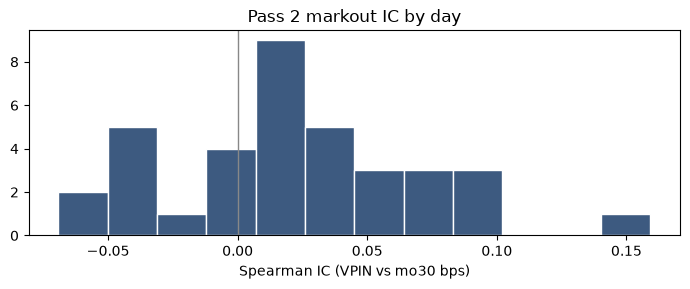

Toxicity join n=73: ρ(vpin,spread)=-0.364 CI=[-0.589,-0.145] — **Hold** (high VPIN ↔ tighter spread on HL+DB sample; monitor-only flag)

In [7]:
mo = jload('pass2/markout.json')
tox = jload('pass2/toxicity.json')
if p2:
    display(Markdown(
        f"**Pass 2 board** (`decisions_pass2.json`): {dec.get('decision_counts')} — "
        f"markout **{p2.get('markout')}**, toxicity **{p2.get('toxicity')}**, xvenue **{p2.get('xvenue')}**"
    ))
if mo.get('n_days_ok'):
    ok = [r for r in mo.get('day_rows', []) if r.get('ok')]
    rhos = pd.Series([r['ic_spearman_vpin_vs_mo30']['rho'] for r in ok])
    display(Markdown(
        f"Ex-ante VPIN vs 30s TOB markout: n_ok days={mo['n_days_ok']}, "
        f"median IC={mo.get('median_ic_by_day'):.4f}, early={mo.get('median_ic_early'):.4f}, late={mo.get('median_ic_late'):.4f}"
    ))
    fig, ax = plt.subplots(figsize=(7,3))
    ax.hist(rhos.dropna(), bins=12, color='#3d5a80', edgecolor='white')
    ax.axvline(0, color='#888', lw=1)
    ax.set_xlabel('Spearman IC (VPIN vs mo30 bps)')
    ax.set_title('Pass 2 markout IC by day')
    plt.tight_layout()
    plt.show()
if tox.get('n_days'):
    display(Markdown(
        f"Toxicity join n={tox['n_days']}: ρ(vpin,spread)={tox['spearman_vpin_spread']['rho']:.3f} "
        f"CI=[{tox['spearman_vpin_spread']['lo']:.3f},{tox['spearman_vpin_spread']['hi']:.3f}] — "
        f"**Hold** (high VPIN ↔ tighter spread on HL+DB sample; monitor-only flag)"
    ))
